In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

Load Alwadi dataset, and clean the data

In [9]:
#Load Alwadi dataset.
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/raw/3339_alwadi'))
csv_file = '3339_alwadi_Attendance_Transactions.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

# Load the CSV file into Dataframe
Dset = pd.read_csv(absolute_path)

# Convert 'TransDataTime' to datetime format
Dset['TransDateTime'] = pd.to_datetime(Dset['TransDateTime'],  format='%Y-%m-%d %H:%M:%S.%f')

print(Dset['TransDateTime'].dtype)
# Create 'transdate' column with just the date
Dset['Transdate'] = Dset['TransDateTime'].dt.date

# Create 'transtime' column with just the time
Dset['Transtime'] = Dset['TransDateTime'].dt.time

9# will keep the requires coulmns and delete the rest.
Data_to_Keep = ['EmployeeId','TransDateTime','Transdate','Transtime','Type','Tag']
Dset_filter = Dset[Data_to_Keep]

datetime64[ns]


C:\Users\fzmaj\AppData\Local\Temp\ipykernel_20948\3509088133.py:7: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  Dset = pd.read_csv(absolute_path)


Delete duplicate if any

In [10]:
Dset_filter.drop_duplicates()

,EmployeeId,TransDateTime,Transdate,Transtime,Type,Tag
0,51990,2024-06-03,2024-06-03,00:00:00,Absence,NaN
1,51995,2024-06-03,2024-06-03,00:00:00,Absence,NaN
2,52071,2024-06-03,2024-06-03,00:00:00,Absence,NaN
3,52074,2024-06-03,2024-06-03,00:00:00,Absence,NaN
4,52082,2024-06-03,2024-06-03,00:00:00,Absence,NaN
...,...,...,...,...,...,...
35309,52950,2024-08-05,2024-08-05,00:00:00,Absence,NaN
35310,52206,2024-08-05,2024-08-05,00:00:00,Absence,NaN
35311,52200,2024-08-05,2024-08-05,00:00:00,Absence,NaN
35312,52171,2024-08-05,2024-08-05,00:00:00,Absence,NaN


Handle Missing action for attendance and absence

In [11]:
# This correction action for "Missing action" based on the correction action for HR Department or the direct Manager fot the Employee

# action1 ->  Update 'Type' where 'Tag' is 'Attend' or 'Leave' and 'Type' is 'Missing Action' )
Dset_filter.loc[(Dset_filter['Type'] == 'Missing Action') & (Dset_filter['Tag'].isin(['Attend', 'Leave'])), 'Type'] = Dset_filter['Tag']


# Action2 -> Delete the reset of the "Missing action" records
Dset_filter = Dset_filter[Dset_filter['Type'] != 'Absence']

# Delete records where 'Type' is 'Absence' - unnecessary information
Dset_filter = Dset_filter[Dset_filter['Type'] != 'Absence']

# Drop the 'Tag' column - no need for it any more
Dset_filter = Dset_filter.drop(columns=['Tag'])
print(Dset_filter)

# Save the data to CSV file 
output_dir = '../../data/processed/3339_alwadi'
os.makedirs(output_dir, exist_ok=True)
Dset_filter.to_csv(os.path.join(output_dir, '3339_alwadi_Prepared_data.csv'), index=False)


       EmployeeId       TransDateTime   Transdate Transtime    Type
626         52015 2024-06-02 11:16:00  2024-06-02  11:16:00  Attend
627         52010 2024-06-02 11:53:00  2024-06-02  11:53:00  Attend
628         52036 2024-06-02 11:54:00  2024-06-02  11:54:00  Attend
629         52058 2024-06-02 11:54:00  2024-06-02  11:54:00  Attend
630         52075 2024-06-02 11:54:00  2024-06-02  11:54:00  Attend
...           ...                 ...         ...       ...     ...
34607       52140 2024-08-02 17:02:00  2024-08-02  17:02:00   Leave
34608       52081 2024-08-02 17:18:00  2024-08-02  17:18:00   Leave
34617       52024 2024-08-02 15:59:00  2024-08-02  15:59:00   Leave
34619       52111 2024-08-02 22:00:00  2024-08-02  22:00:00   Leave
34620       52120 2024-08-02 22:00:00  2024-08-02  22:00:00   Leave

[29896 rows x 5 columns]


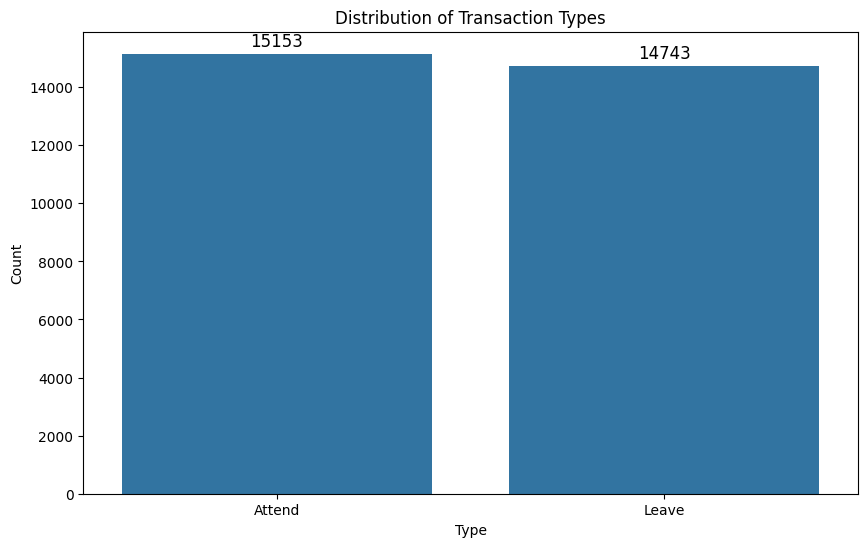

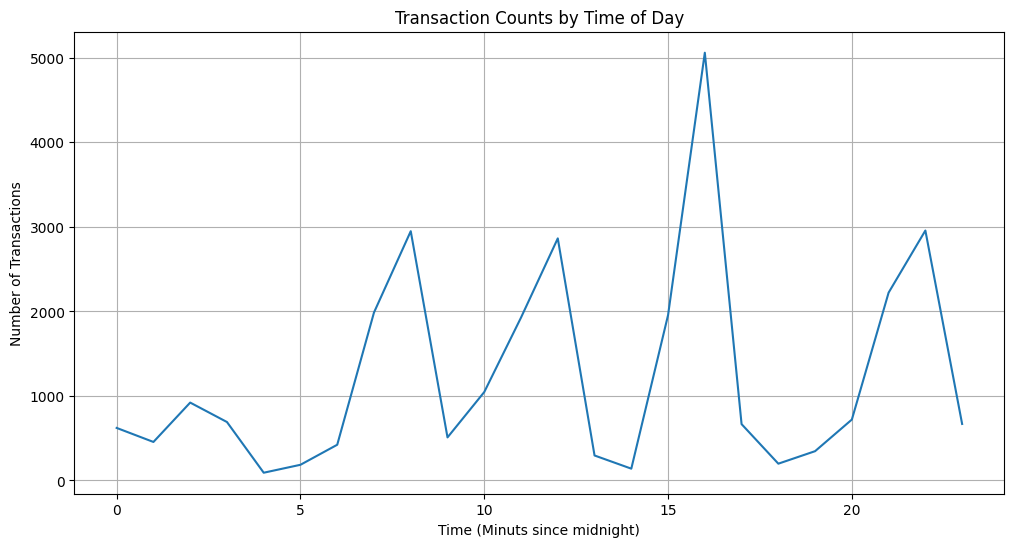

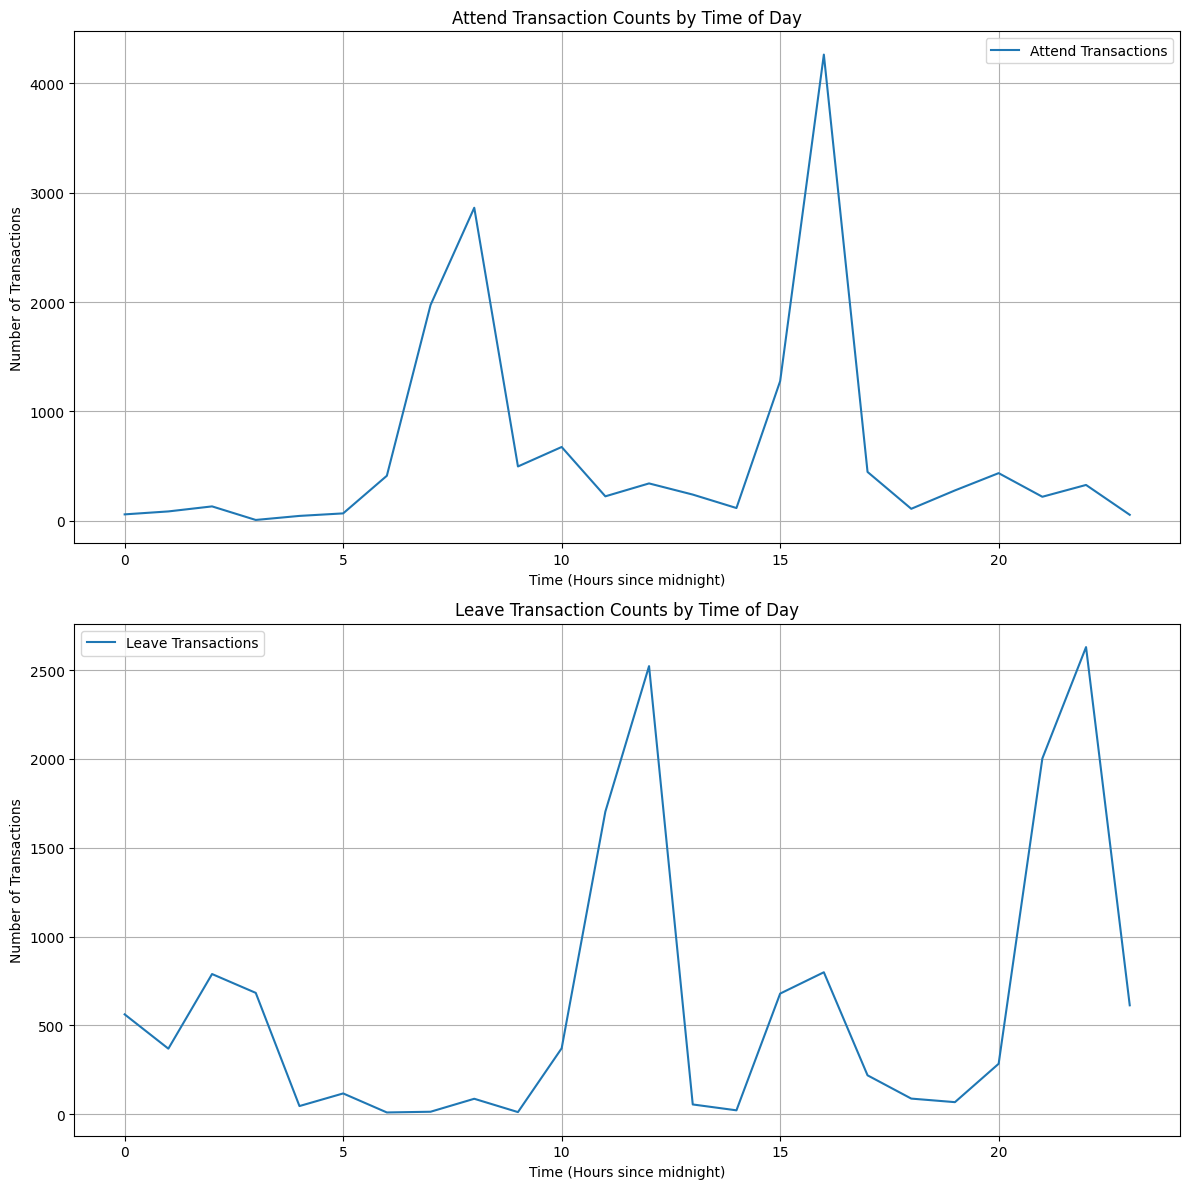

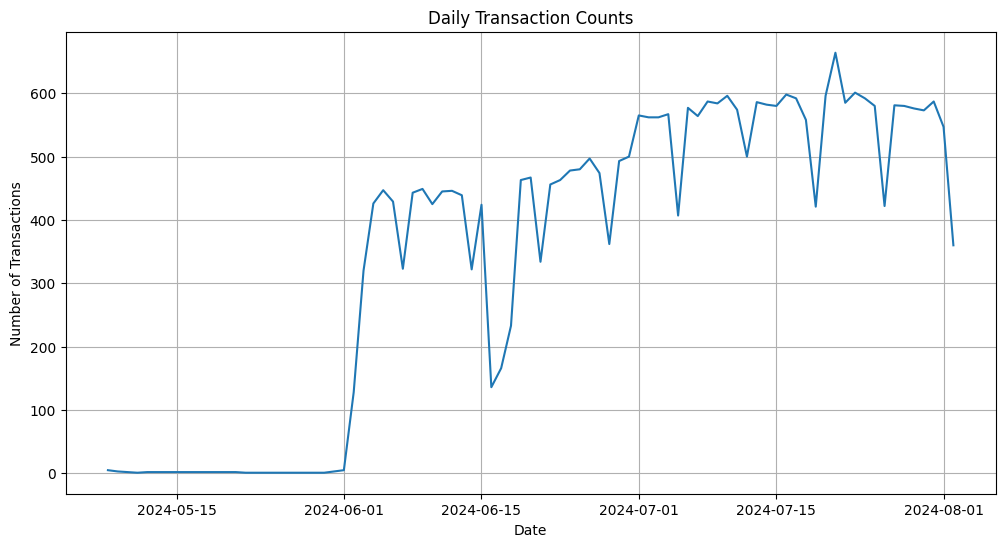

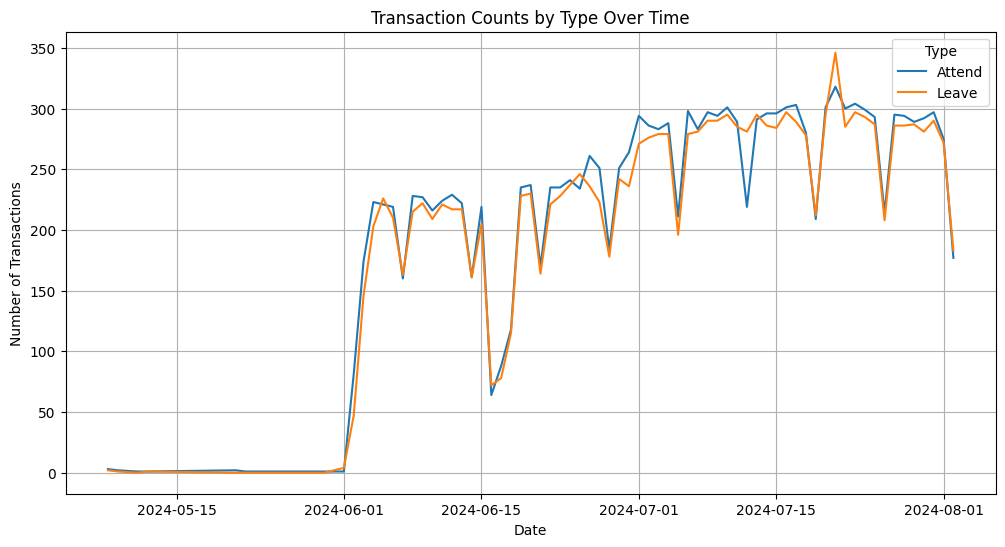

In [12]:

# Distribution of 'Type' - Attend & Leave
plt.figure(figsize=(10, 6))
sns.countplot(x='Type', data=Dset_filter)
plt.title('Distribution of Transaction Types')
plt.xlabel('Type')
plt.ylabel('Count')
# add counts to the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.show()

# Convert 'TransTime' to hours since midnight for easier plotting
def time_to_hours(t):
    return t.hour 

Dset_filter['TransTimeHours'] = Dset_filter['Transtime'].apply(time_to_hours)
time_distribution = Dset_filter.groupby('TransTimeHours').size()

# Plot distribution of transactions by time of day
plt.figure(figsize=(12, 6))
plt.plot(time_distribution.index, time_distribution.values)
plt.title('Transaction Counts by Time of Day')
plt.xlabel('Time (Minuts since midnight)')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

def time_to_minutes(t):
    return t.hour  # Simplified to only get hours

# Assuming Dset_filter is your DataFrame and it contains the 'Transtime' column formatted correctly
Dset_filter['Transtime'] = pd.to_datetime(Dset_filter['Transtime'], format='%H:%M:%S')  # Convert time strings to datetime objects if not already
Dset_filter['TransTimeHours'] = Dset_filter['Transtime'].dt.time.apply(time_to_minutes)

# Plotting function to avoid repetition
def plot_transactions(data, transaction_type, ax):
    filtered_data = data[data['Type'] == transaction_type]
    time_distribution = filtered_data.groupby('TransTimeHours').size()
    
    ax.plot(time_distribution.index, time_distribution.values, label=f'{transaction_type} Transactions')
    ax.set_title(f'{transaction_type} Transaction Counts by Time of Day')
    ax.set_xlabel('Time (Hours since midnight)')
    ax.set_ylabel('Number of Transactions')
    ax.grid(True)
    ax.legend()

# Create a figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 12))

# Plot Attend Transactions
plot_transactions(Dset_filter, 'Attend', axs[0])

# Plot Leave Transactions
plot_transactions(Dset_filter, 'Leave', axs[1])

plt.tight_layout()
plt.show()

# Aggregate data by 'TransDate'
daily_counts = Dset_filter.groupby('Transdate').size()

# Plot daily transaction counts
plt.figure(figsize=(12, 6))
daily_counts.plot()
plt.title('Daily Transaction Counts')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

# Aggregating by 'Type' and 'TransDate'
type_counts = Dset_filter.groupby(['Transdate', 'Type']).size().unstack().fillna(0)

# Plotting aggregated counts by type
type_counts.plot(figsize=(12, 6))
plt.title('Transaction Counts by Type Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()





In [6]:
# Filter for Type 'Leave' and 'Attend'
filtered_df = Dset_filter[Dset_filter['Type'].isin(['Leave', 'Attend'])]

# Count transactions per day for each EmployeeId and Type
transaction_counts = filtered_df.groupby(['EmployeeId', 'Transdate', 'Type']).size().reset_index(name='TransactionCount')

# Filter to show only where the transaction count > 2
transaction_counts_filtered = transaction_counts[transaction_counts['TransactionCount'] > 2]

# Pivot the table for better readability
pivot_table = transaction_counts_filtered.pivot_table(index=['EmployeeId', 'Transdate'], columns='Type', values='TransactionCount', fill_value=0)

# Display the result
print(pivot_table)
# Save the data to CSV file and Ensure directory exists
#output_dir = '../../data/processed/3339_alwadi'
#os.makedirs(output_dir, exist_ok=True)
#pivot_table.to_csv(os.path.join(output_dir, 'alwadi_attend_leave_GThan_2.csv'), index=False)

Type                   Attend  Leave
EmployeeId Transdate                
51835      2024-05-08     3.0    0.0
51987      2024-07-02     3.0    0.0
51992      2024-06-02     3.0    0.0
           2024-07-01     0.0    3.0
           2024-07-22     3.0    0.0
...                       ...    ...
52952      2024-07-13     0.0    3.0
           2024-07-16     0.0    3.0
           2024-07-20     0.0    3.0
           2024-07-24     0.0    3.0
           2024-07-27     3.0    0.0

[424 rows x 2 columns]


In [7]:
transaction_counts = filtered_df.groupby(['EmployeeId', 'Transdate', 'Type']).size().reset_index(name='TransactionCount')

# Filter to show only where the transaction count > 2
transaction_counts_filtered = transaction_counts[transaction_counts['TransactionCount'] <= 2]

# Pivot the table for better readability
pivot_table = transaction_counts_filtered.pivot_table(index=['EmployeeId', 'Transdate'], columns='Type', values='TransactionCount', fill_value=0)

# Display the result
print(pivot_table)
#pivot_table.to_csv(os.path.join(output_dir, 'alwadi_attend_leave_LThan_3.csv'), index=False)


Type                   Attend  Leave
EmployeeId Transdate                
51835      2024-05-08     0.0    2.0
           2024-05-09     1.0    1.0
           2024-05-11     1.0    0.0
           2024-05-12     1.0    1.0
           2024-05-23     1.0    0.0
...                       ...    ...
52952      2024-07-29     2.0    2.0
           2024-07-30     2.0    2.0
           2024-07-31     2.0    2.0
           2024-08-01     2.0    2.0
           2024-08-02     1.0    2.0

[9673 rows x 2 columns]
